In [16]:
from pocketgrad.engine import Scalar
from pocketgrad.visualize import draw_graph

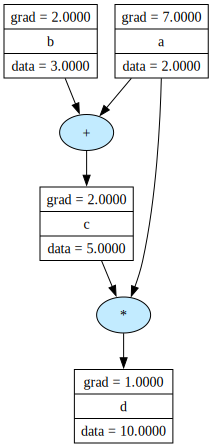

In [17]:
# Our first computational graph
a = Scalar(2.0, label="a")
b = Scalar(3.0, label="b")

c = a + b; c.label = "c"
d = a * c; d.label = "d"

d.backward()
draw_graph(d)

### Symbolic Differentiation

$$
\begin{aligned}
a &= 2 \\
b &= 3 \\
c &= a + b \\
d &= a * c \\\\

\text{d.grad} &= \frac{\partial d}{\partial d} = 1 \\

\text{c.grad} &= \frac{\partial d}{\partial c} = \frac{\partial (a \cdot c)}{\partial c} = a = 2 \\

\text{b.grad} &= \frac{\partial d}{\partial b} = \frac{\partial (a \cdot c)}{\partial c} \cdot \frac{\partial (a+b)}{\partial b} = 2 \cdot 1 = 2 \\

\text{a.grad} &= \frac{\partial d}{\partial a} = \underbrace{\frac{\partial (a \cdot c)}{\partial a}}_{\text{path-1}} + \underbrace{\frac{\partial (a \cdot c)}{\partial c} \cdot \frac{\partial (a+b)}{\partial a}}_{\text{path-2}} = c + a = 5 + 2 = 7
\end{aligned}
$$


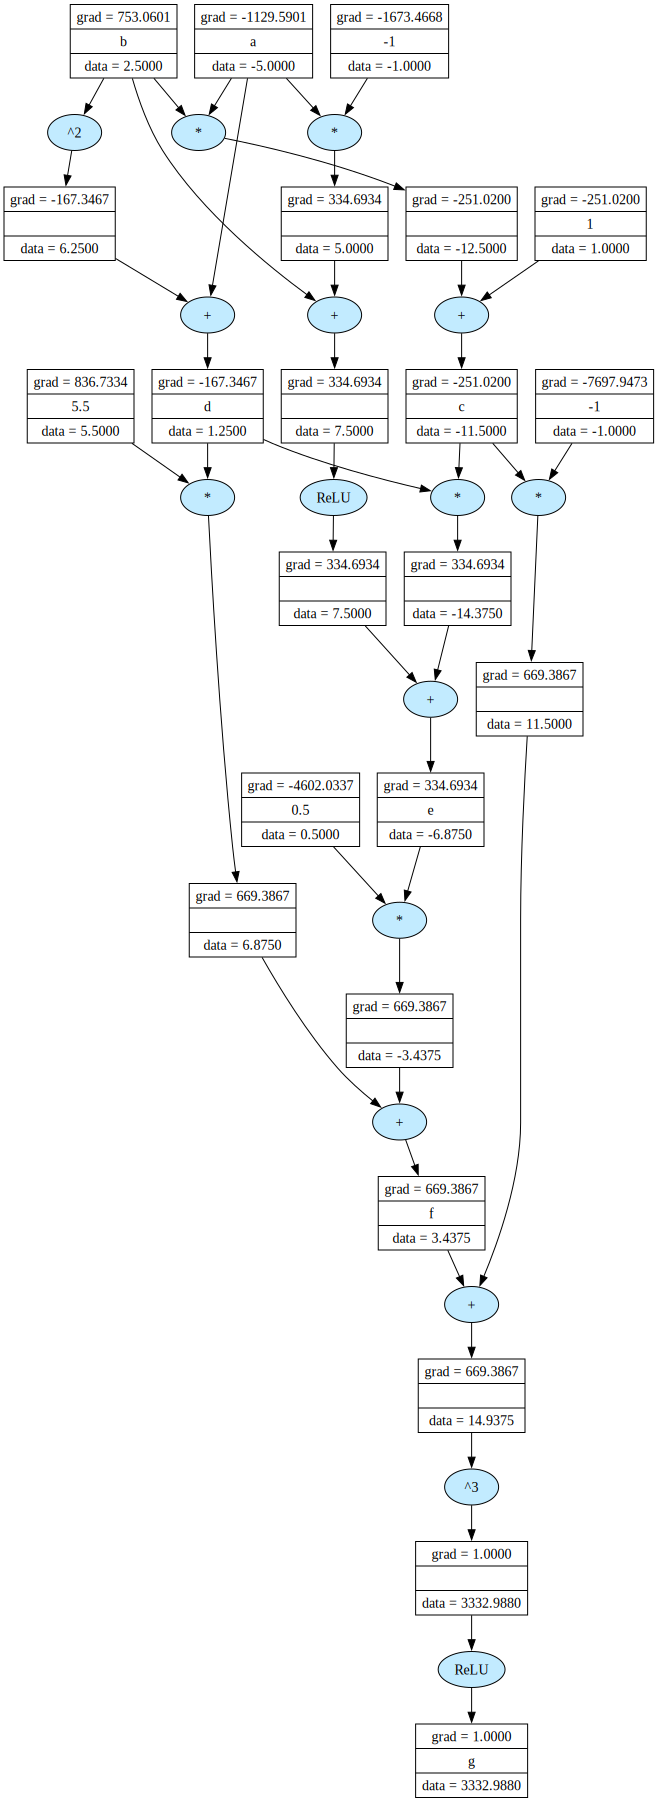

In [18]:
# More complex computational graph
a = Scalar(-5.0, label="a")
b = Scalar(2.5, label="b")

c = a * b + 1;              c.label = "c"
d = a + b**2;               d.label = "d"
e = c * d + (b - a).relu(); e.label = "e"
f = (e / 2.0 + 5.5 * d);    f.label = "f"
g = ((f - c) ** 3).relu();  g.label = "g"

g.backward()
draw_graph(g)

##### Good luck differentiating this one by hand :)